In [ ]:
#setup del notebook, aseguramos instalar las librerias necesarias
#pip install matplotlib numpy pandas seaborn sklearn.model
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from IPython.display import display



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


# Comenzamos la exploración de los datos

In [ ]:
df = pd.read_csv(r"C:\Users\inglu\maching learning\Tarea_parcial_3\benford_training_data.csv")  #  cargado el dataframe
# Creamos un DataFrame con resumen de columnas
info_df = pd.DataFrame({
    'Columna': df.columns,
    'Tipo de dato': df.dtypes.values,
    'nulos': df.isnull().sum().values,
    'Valores únicos': df.nunique().values
})

# Mostramos la tabla 
display(info_df)

# Mostramos la cantidad de entradas totales
print('entradas totales',len(df))

,Columna,Tipo de dato,nulos,Valores únicos
0,chi2_stat,float64,0,1279
1,chi2_pvalue,float64,0,1276
2,mad,float64,0,1021
3,ks_distance,float64,0,984
4,freq_digit_1,float64,0,820
5,freq_digit_9,float64,0,817
6,freq_digits_1_2,float64,0,841
7,freq_variance,float64,0,1256
8,euclidean_distance,float64,0,1279
9,is_fraud,int64,0,2


entradas totales 1280


Podemos observar que tenemos 9 columnas distintas, 8 de ellas están en un tipo de dato float, lo cual coincide con lo que se espera de cada una de ellas, is_fraud está en un tipo de dato entero, con dos valores únicos, lo que concide con lo esperado: un valor booleano. El total de entradas es de 1280.

## Valores descriptivos


In [ ]:
# Agrupamos por is_fraud y calculamos estadísticas descriptivas para los dígitos de Benford
summary_benford = df.groupby('is_fraud')[
    ['freq_digit_1', 'freq_digits_1_2', 'freq_digit_9']
].describe().T

# redondeamos para mejor visualización
summary_benford = summary_benford.round(4)

# Mostramos con display 
display(summary_benford)

is_fraud                      0         1
freq_digit_1    count  640.0000  640.0000
                mean     0.3132    0.2063
                std      0.1101    0.2239
                min      0.0071    0.0000
                25%      0.2761    0.0000
                50%      0.3015    0.1159
                75%      0.3291    0.3646
                max      0.8588    0.7667
freq_digits_1_2 count  640.0000  640.0000
                mean     0.4864    0.2849
                std      0.1273    0.2709
                min      0.0139    0.0000
                25%      0.4554    0.0000
                50%      0.4800    0.2253
                75%      0.5119    0.5565
                max      0.9873    0.8491
freq_digit_9    count  640.0000  640.0000
                mean     0.0487    0.1129
                std      0.0313    0.0511
                min      0.0000    0.0000
                25%      0.0328    0.0751
                50%      0.0447    0.1128
                75%      0.0580    0.1509
                max      0.2444    0.2533

Lo primero que podemos observar es que nuestra variable objetivo is_fraud (y) se encuentra balanceada, ya que tiene la misma cantidad de entradas para datos que son un fraude(1) como de entradas que no son fraude(0).

Adicionalmente, podemos saber que los datos que fueron catalogados como no fraude poseen posiblemente una distribución normal debido a que su media aritmetica y la mediana tienen casi el mismo valor para las distintas frequencias, además de tener poca dispersión. Por otro lado, los datos catalogados como fraude no siguen una distribución normal, la media aritmetica y la mediana posen diferencias notables y una dispersión elevada.

Ahora, vamos a comparar las frecuencias para cada una de la etiquetas en contra del valor esperado para la ley de Benford.


In [ ]:
#creamos una funcion para calcular los valores esperados de Benford
def benford_prob(d):
    """
    Calcula la probabilidad esperada según la Ley de Benford para un número d.

    Parámetros:
    - d (int): el dígito o número inicial.

    Retorna:
    - Probabilidad esperada (como decimal, no porcentaje).
    """
    if d < 1:
        raise ValueError("El número d debe ser mayor o igual a 1")
    return np.log10(1 + 1 / d)

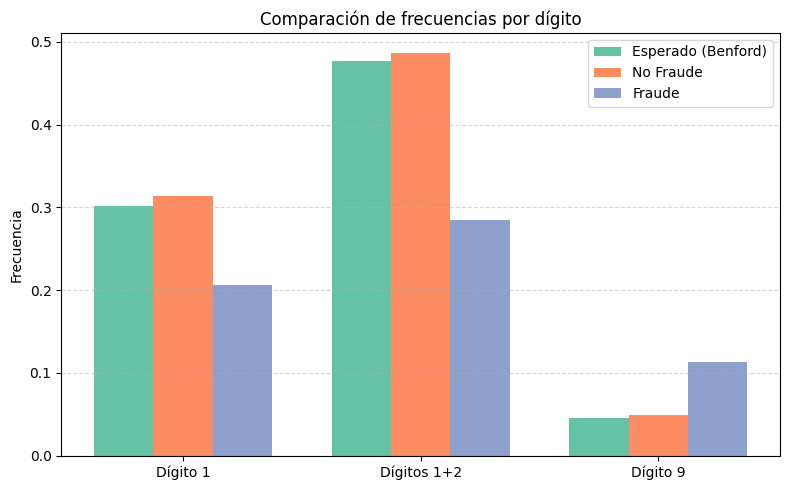

In [ ]:
# Extraer medias por grupo 
mean_no_fraude = summary_benford.loc[(slice(None), 'mean'), 0]
mean_fraude = summary_benford.loc[(slice(None), 'mean'), 1]

# Calculamos el valor experado de Benford
freq_esperada_digit_1=benford_prob(1)
freq_esperada_digit_1_2=benford_prob(1)+benford_prob(2)
freq_esperada_digit_9=benford_prob(9)

freq_esperada = pd.Series(
    [freq_esperada_digit_1, freq_esperada_digit_1_2, freq_esperada_digit_9],
    index=['freq_digit_1', 'freq_digits_1_2', 'freq_digit_9']
)

# Preparar datos para gráfico
labels = ['freq_digit_1', 'freq_digits_1_2', 'freq_digit_9']

esperado = freq_esperada[labels].values
no_fraude = mean_no_fraude[labels].values
fraude = mean_fraude[labels].values

#Grafica
x = np.arange(len(labels))
width = 0.25

# Definir paleta con seaborn
palette = sns.color_palette("Set2", 3)  # 3 colores para nuestras 3 categorías

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width, esperado, width, label='Esperado (Benford)', color=palette[0])
ax.bar(x, no_fraude, width, label='No Fraude', color=palette[1])
ax.bar(x + width, fraude, width, label='Fraude', color=palette[2])

ax.set_ylabel('Frecuencia')
ax.set_title('Comparación de frecuencias por dígito')
ax.set_xticks(x)
ax.set_xticklabels(['Dígito 1', 'Dígitos 1+2', 'Dígito 9'])
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Podemos observar en el gráfico de barras agrupado que los datos etiquetados como No Fraude se asemejan mucho a lo esperado por la ley de Benford, mientras que los datos etiquetados como fraude se desvían mucho del valor esperado lo que indica que no siguen la ley de Benford, siendo la más evidente la del noveno dígito, ya que esta casi dobla el valor esperado. 


# Preparación de datos

### Separación de características

In [ ]:
# Variable objetivo
y = df['is_fraud']

# Características: todas las columnas menos 'is_fraud'
X = df.drop(columns=['is_fraud'])

### Creación de los subconjuntos entrenamiento y validación

In [ ]:
# Split 80% entrenamiento, 20% validación
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.20, random_state=12, stratify=y
)

print(f"Tamaño entrenamiento: {len(X_train)}")
print(f"Tamaño validación: {len(X_val)}")

Tamaño entrenamiento: 1024
Tamaño validación: 256


En este apartado vamos a hacer una justificación de por qué se decidió tomar un 20% de validación y un 80% para el entrenamiento:

Se eligió un split 80/20 porque permite utilizar la mayor cantidad posible de datos para el entrenamiento, lo cual beneficia el rendimiento del modelo, especialmente en algoritmos como KNN que funcionan mejor con más información. El otro algoritmo que vamos a utilizar es el Random Forest, el cual es un poco más robusto, pero que igual se beneficiará de tener una mayor cantidad de datos de entranamiento.

Además, dado que el conjunto total tiene 1280 ejemplos, asignar solo el 20% a validación (256 datos) sigue siendo suficiente para obtener una evaluación razonable con suficiente variabilidad, mientras que el 80% restante (1024 datos) mejora el aprendizaje del modelo. Esta es una decisión estratégica para aprovechar mejor el tamaño del dataset, sin comprometer la evaluación del desempeño, ya que el tamaño de la validación es similar en tamaño al test data.


### Normalización de los datos

In [ ]:
# KNN: Normalizar 
scaler = StandardScaler()
X_train_knn = scaler.fit_transform(X_train)
X_val_knn = scaler.transform(X_val)


Dado que el modelo de Random Forest no requiere la normalización de datos y para evitar un posible impacto negativo en su rendimiento, utilizaremos el conjunto de datos x_train sin normalizar para entrenarlo.

## Entrenamiento del modelo

### Modelo KNN o vecinos más cercanos

In [ ]:
#Evaluar diferentes valores de k
neighbors_list = [3, 5, 7, 9]
results = []

for k in neighbors_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train)
    accuracy = knn.score(X_val_knn, y_val)
    results.append({'n_neighbors': k, 'accuracy': accuracy})

#Mostrar tabla ordenada
results_df = pd.DataFrame(results)
display(results_df.sort_values(by='accuracy', ascending=False))

,n_neighbors,accuracy
1,5,0.960938
2,7,0.957031
3,9,0.957031
0,3,0.953125


### Ramdon Forest

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=12)
rf.fit(X_train, y_train)
rf_score = rf.score(X_val, y_val)
print('Accuracy',rf_score)

Accuracy 0.953125


# Evaluación y comparación

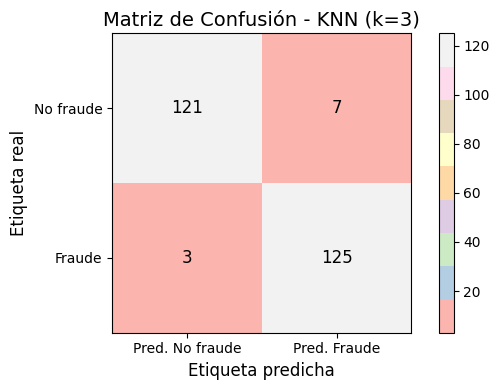

In [ ]:
#KNN
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
labels = ['No fraude', 'Fraude']
knn = KNeighborsClassifier(5)
knn.fit(X_train_knn, y_train)
accuracy = knn.score(X_val_knn, y_val)
y_pred_knn = knn.predict(X_val_knn)
cm_knn = confusion_matrix(y_val, y_pred_knn)

labels = ['No fraude', 'Fraude']

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(cm_knn, interpolation='nearest', cmap=plt.cm.Pastel1)

# Título y etiquetas
ax.set_title("Matriz de Confusión - KNN (k=5)", fontsize=14)
ax.set_xlabel("Etiqueta predicha", fontsize=12)
ax.set_ylabel("Etiqueta real", fontsize=12)
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(['Pred. No fraude', 'Pred. Fraude'])
ax.set_yticklabels(labels)

# Mostramos los valores en las celdas
for i in range(cm_knn.shape[0]):
    for j in range(cm_knn.shape[1]):
        ax.text(j, i, cm_knn[i, j], ha="center", va="center", color="black", fontsize=12)

# Ajustes finales
plt.tight_layout()
plt.colorbar(im)
plt.show()



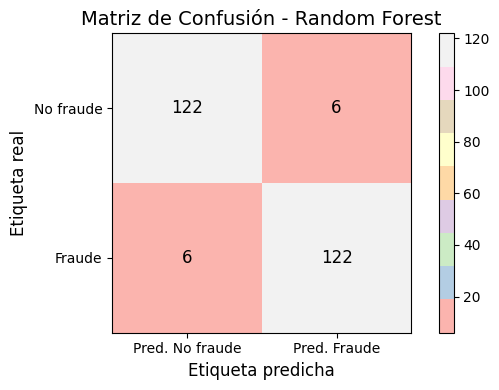

In [ ]:
#Hacer predicciones en el conjunto de validación
y_pred_rf = rf.predict(X_val)

#Calcular la matriz de confusión
cm_rf = confusion_matrix(y_val, y_pred_rf)

#Visualizar la matriz con etiquetas legibles
#Etiquetas
labels = ['No fraude', 'Fraude']
cm_rf = confusion_matrix(y_val, y_pred_rf)

# Crear figura
fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(cm_rf, interpolation='nearest', cmap=plt.cm.Pastel1)

# Título y etiquetas
ax.set_title("Matriz de Confusión - Random Forest", fontsize=14)
ax.set_xlabel("Etiqueta predicha", fontsize=12)
ax.set_ylabel("Etiqueta real", fontsize=12)
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(['Pred. No fraude', 'Pred. Fraude'])
ax.set_yticklabels(labels)

# Mostrar los valores en las celdas
for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        ax.text(j, i, cm_rf[i, j], ha="center", va="center", color="black", fontsize=12)

# Ajustes finales
plt.tight_layout()
plt.colorbar(im)
plt.show()

Interpretación de Resultados:
- Precisión general: El KNN (k=5) acierta en el 96.09% de los casos, mientras que el Random Forest acierta en el 95.31%. No es una diferencia enorme, pero el KNN tiene un mejor rendimiento.

- Errores críticos (Falsos Negativos). El KNN solo falla en 3 casos de fraude, mientras que el Random Forest falla en 6. Esto significa que el KNN es más seguro, ya que deja pasar menos fraudes sin detectar.

- Errores menos graves (Falsos Positivos). El KNN comete 7 errores de este tipo, y el Random Forest 6, es decir, la penalidad de molestar a los clientes con falsos positivos es similar en ambos modelos.

Por lo tanto, el modelo KNN es el mejor en comparación.

### Respuestas a preguntas claves

1. ¿Qué valor de k fue el más efectivo en KNN? De la pruebas realizadas (k=3, 5, 7, 9), el k=5 fue el mas efectivo con 96.09% de precision.

2. ¿Qué errores son más graves: falsos positivos o falsos negativos? Los falsos negativos son peores porque dejan pasar fraudes reales, lo que significa pérdidas económicas directas para la empresa/compañía. Los falsos positivos solo pueden generar molestias al cliente al bloquear transacciones legítimas, lo cual es un problema menor comparado con el costo de no detectar fraudes.

3. ¿Cuál modelo usarías en una aplicación real y por qué? El algoritmo KNN con k=5 representa la mejor opción para implementación en un entorno real de detección de fraudes, ya que este modelo destaca por su quilibrio óptimo entre capacidad predictiva y eficiencia operacional, siendo superior en aspectos críticos para este tipo de sistemas, en donde la principal ventaja radica en su configuración de vecindad que le permite identificar con mayor precisión patrones fraudulentos manteniendo una tasa manejable de falsas alarmas.

El KNN supera a alternativas como Random Forest al ofrecer una detección más precisa de casos positivos reales, minimizando así el riesgo financiero asociado a fraudes no detectados. Tambien, su arquitectura simplificada proporciona ventajas adicionales en términos de velocidad de procesamiento y adaptabilidad a diferentes patrones de transacciones, características esenciales para sistemas que operan en tiempo real con grandes volúmenes de datos.

Considerando estos factores, el KNN se posiciona como la solución más adecuada para instituciones que requieran un sistema antifraude confiable, eficaz y viable. Su adopción proporcionaría beneficios tanto en la reducción de pérdidas económicas como en la mantención de estándares de servicio al cliente.

